In [19]:
import rich
import yaml
import gzip
import hist
import numpy as np
import mplhep as hep
import correctionlib
import correctionlib.convert
from coffea.util import load
import matplotlib.pyplot as plt
from coffea.processor import accumulate

with open("../analysis/postprocess/style.yaml", "r") as f:
    style = yaml.safe_load(f)
with open("../analysis/postprocess/luminosity.yaml", "r") as f:
    lumi = yaml.safe_load(f)
plt.rcParams.update(style["rcParams"])

In [ ]:
year = "2022preEE"
run_key = "2" if year.startswith("201") else "3"
energy = {"2": "13", "3": "13.6"}
workflow = "1b1mu"
xlabels = {
    "2b1mu": r"$S_T(\mu, b, p_T^{miss})$ [GeV]",
    "2b1e": r"$S_T(e, 2b, p_T^{miss})$ [GeV]",
    "1b1mu1e": r"$S_T(e, \mu, p_T^{\text{miss}}, b)$ [GeV]",
    "1b1e1mu": r"$S_T(e, \mu, p_T^{\text{miss}}, b)$ [GeV]"
}

ph = load(f"/eos/user/d/driosper/bsm3g_coffea_outputs/{workflow}/{year}/{year}_processed_histograms.coffea")

tt = ph["tt"]["st"][{"variation": "nominal"}]
data = ph["Data"]["st"][{"variation": "nominal"}]
nontt = accumulate(
    [
        ph["DYJetsToLL"]["st"][{"variation": "nominal"}],
        ph["SingleTop"]["st"][{"variation": "nominal"}],
        ph["WJetsToLNu"]["st"][{"variation": "nominal"}],
        ph["Diboson"]["st"][{"variation": "nominal"}],
    ]
)
fig, ax = plt.subplots(figsize=(10,10))
data.plot2d(ax=ax);

KeyError: 'Data'

[Text(0.5, 73.19444444444443, '$S_T(e, 2b, p_T^{miss})$ [GeV]'),
 Text(95.25, 0.5, 'lightjets multiplicity')]

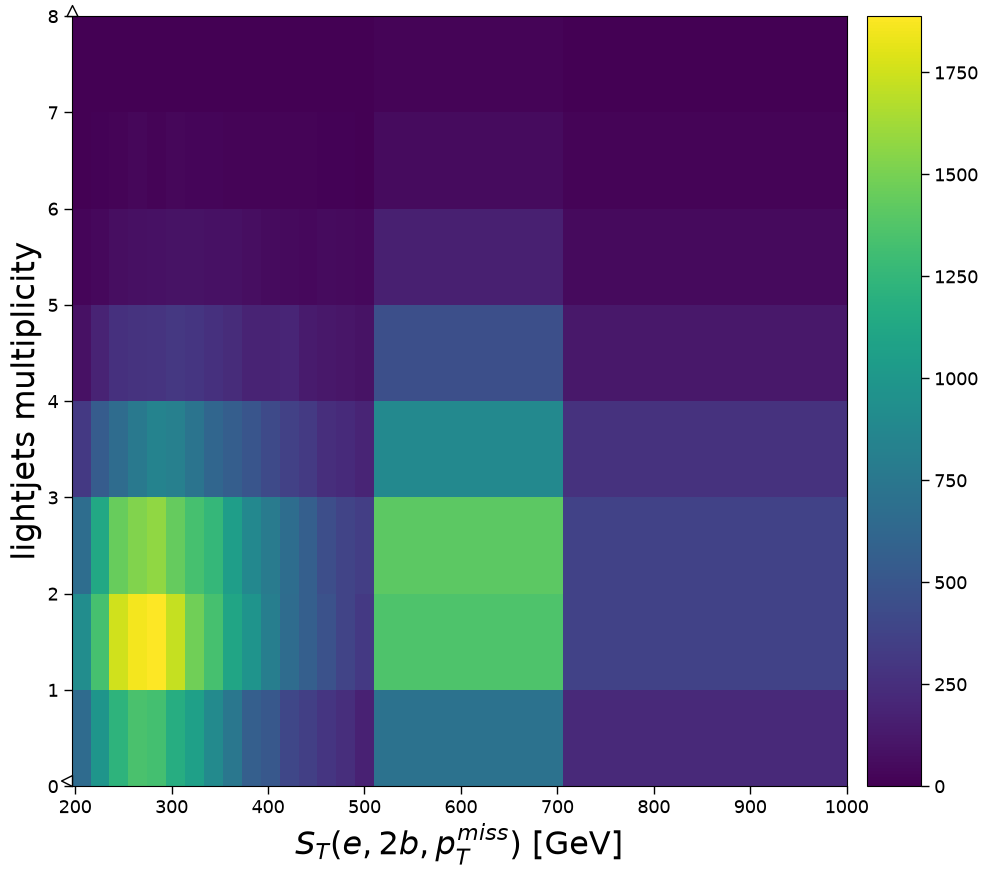

In [ ]:
def rebin_hist(h, axis_name, edges):
    if type(edges) == int:
        return h[{axis_name: hist.rebin(edges)}]

    ax = h.axes[axis_name]
    ax_idx = [a.name for a in h.axes].index(axis_name)
    if not all([np.isclose(x, ax.edges).any() for x in edges]):
        raise ValueError(
            f"Cannot rebin histogram due to incompatible edges for axis '{ax.name}'\n"
            f"Edges of histogram are {ax.edges}, requested rebinning to {edges}"
        )

    # Keep overflow/underflow when rebinning to a sub-range
    overflow = ax.traits.overflow or (
        edges[-1] < ax.edges[-1] and not np.isclose(edges[-1], ax.edges[-1])
    )
    underflow = ax.traits.underflow or (
        edges[0] > ax.edges[0] and not np.isclose(edges[0], ax.edges[0])
    )
    flow = overflow or underflow
    new_ax = hist.axis.Variable(
        edges, name=ax.name, overflow=overflow, underflow=underflow
    )
    axes = list(h.axes)
    axes[ax_idx] = new_ax

    # Updated: access storage_type as a public attribute
    hnew = hist.Hist(*axes, name=h.name, storage=h.storage_type())

    # Offset from bin edge to avoid numeric issues
    offset = 0.5 * np.min(ax.edges[1:] - ax.edges[:-1])
    edges_eval = edges + offset
    edge_idx = ax.index(edges_eval)

    if edge_idx[-1] == ax.size + ax.traits.overflow:
        edge_idx = edge_idx[:-1]

    if underflow:
        if ax.traits.underflow:
            edge_idx += 1
        edge_idx = np.insert(edge_idx, 0, 0)

    hnew.values(flow=flow)[...] = np.add.reduceat(
        h.values(flow=flow), edge_idx, axis=ax_idx
    ).take(indices=range(new_ax.size + underflow + overflow), axis=ax_idx)

    # Updated: access storage_type as a public attribute
    if hnew.storage_type == hist.storage.Weight:
        hnew.variances(flow=flow)[...] = np.add.reduceat(
            h.variances(flow=flow), edge_idx, axis=ax_idx
        ).take(indices=range(new_ax.size + underflow + overflow), axis=ax_idx)

    return hnew


st_new_edges = [
    196.4,
    216.0,
    235.6,
    255.2,
    274.8,
    294.4,
    314.0,
    333.6,
    353.2,
    372.8,
    392.4,
    412.0,
    431.6,
    451.2,
    470.8,
    490.4,
    510.0,
    706.0,
    1000,
]

njet_new_edges = [0,1,2, 3, 4, 5, 6, 7, 8]

tt = rebin_hist(tt, "st", st_new_edges)
data = rebin_hist(data, "st", st_new_edges)
nontt = rebin_hist(nontt, "st", st_new_edges)

tt = rebin_hist(tt, "lightjets_multiplicity", njet_new_edges)
data = rebin_hist(data, "lightjets_multiplicity", njet_new_edges)
nontt = rebin_hist(nontt, "lightjets_multiplicity", njet_new_edges)

fig, ax = plt.subplots(figsize=(10,10))
data.plot2d(ax=ax)
ax.set(xlabel=xlabels[workflow], ylabel="lightjets multiplicity")

In [ ]:
# compute SF 
num = (data + (-1 * nontt)).values()
den = tt.values()
sf = np.where((num > 0) & (den > 0), num / (den + 1e-32), 1)
sfhist = hist.Hist(*data.axes[:], data=sf)

# build correctionlib object from histogram
sfhist.name = "boost_weight"
sfhist.label = "out"
boost_weight = correctionlib.convert.from_histogram(sfhist)
boost_weight.description = "tt boost weights"
# set overflow bins behavior (default is to raise an error when out of bounds)
boost_weight.data.flow = "clamp"
rich.print(boost_weight)

📈 boost_weight (v0)
tt boost weights
Node counts: MultiBinning: 1
╭────────────── ▶ input ──────────────╮ ╭─────────── ▶ input ────────────╮
│ st (real)                           │ │ lightjets_multiplicity (real)  │
│ st                                  │ │ lightjets_multiplicity         │
│ Range: [196.4, 1000.0), overflow ok │ │ Range: [0.0, 8.0), overflow ok │
╰─────────────────────────────────────╯ ╰────────────────────────────────╯
╭─── ◀ output ───╮
│ out (real)     │
│ No description │
╰────────────────╯

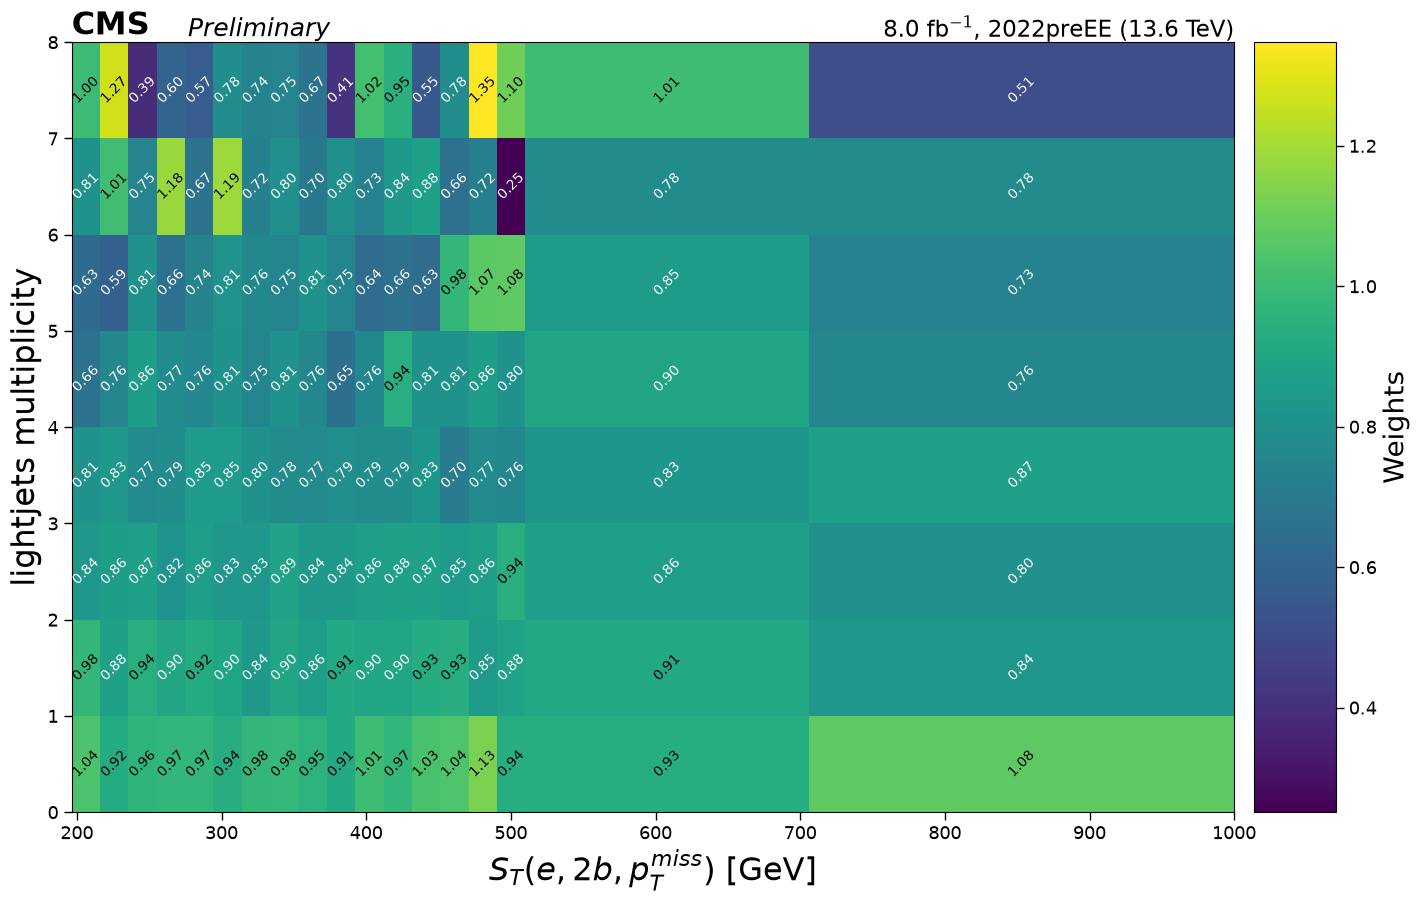

In [ ]:
st_bins = data.project("st").axes.edges[0]
n_jets_bins = data.project("lightjets_multiplicity").axes.edges[0]
st_centers = data.project("st").axes.centers[0]
jet_centers = data.project("lightjets_multiplicity").axes.centers[0]
st, jet_n = np.meshgrid(st_bins, n_jets_bins)
SF = boost_weight.to_evaluator().evaluate(st, jet_n)

data_matrix = np.zeros((len(st_bins)-1, len(n_jets_bins)-1))
for y in range(SF.shape[0]-1):
    for x in range(SF.shape[1]-1):
        data_matrix[x, y] = SF[y, x]

fig, ax = plt.subplots(figsize=(15, 10))
boost_hist = hist.Hist(*data.axes[:], data=data_matrix)
colormesh = boost_hist.plot2d(ax=ax)
colormesh[1].set_label("Weights", fontsize=20)
ax.set(xlabel=xlabels[workflow], ylabel="lightjets multiplicity")

for i in range(data_matrix.shape[0]):
    for j in range(data_matrix.shape[1]):
        val = data_matrix[i, j]
        x = st_centers[i]
        y = jet_centers[j]
        if val < 0.9 or np.isnan(val):
            col = 'w'
        else:
            col = 'k'
        ax.text(x, y, f"{val:.2f}", rotation=45, ha="center", va="center", fontsize=10, color=col)

hep.cms.label(
    ax=ax,
    lumi=round(lumi[year] * 1e-3, 1),
    com=energy[run_key].split()[0],
    data=True,
    year=year
)

ax.text(
    0.1, 1.00,
    r"$\mathit{Preliminary}$", 
    verticalalignment="bottom", 
    horizontalalignment="left", 
    transform=ax.transAxes, 
    fontsize=18
)
fig.savefig(f"plots/boost_weight_{workflow}_{year}.png")
fig.savefig(f"plots/boost_weight_{workflow}_{year}.pdf")

In [ ]:
# Fit to polynomial of order 2,2
centers = np.meshgrid(*[ax.centers for ax in sfhist.axes], indexing="ij")
boost_weight, fit = correctionlib.convert.ndpolyfit(
    points=[c.flatten() for c in centers],
    values=sfhist.values().flatten(),
    weights=1 / sfhist.variances().flatten(),
    varnames=[ax.name for ax in sfhist.axes],
    degree=(2, 2),
)
boost_weight.name = "boost_weight"
rich.print(boost_weight)

📈 boost_weight (v1)
Fit to polynomial of order 2,2
Fit status: The unconstrained solution is optimal.
chi2 = 3.129546938071938, P(dof=135) = 1.000
Node counts: Formula: 1
╭───────── ▶ input ──────────╮ ╭─────────── ▶ input ───────────╮
│ st (real)                  │ │ lightjets_multiplicity (real) │
│ No description             │ │ No description                │
│ Range: unused, overflow ok │ │ Range: unused, overflow ok    │
╰────────────────────────────╯ ╰───────────────────────────────╯
╭─── ◀ output ───╮
│ output (real)  │
│ No description │
╰────────────────╯

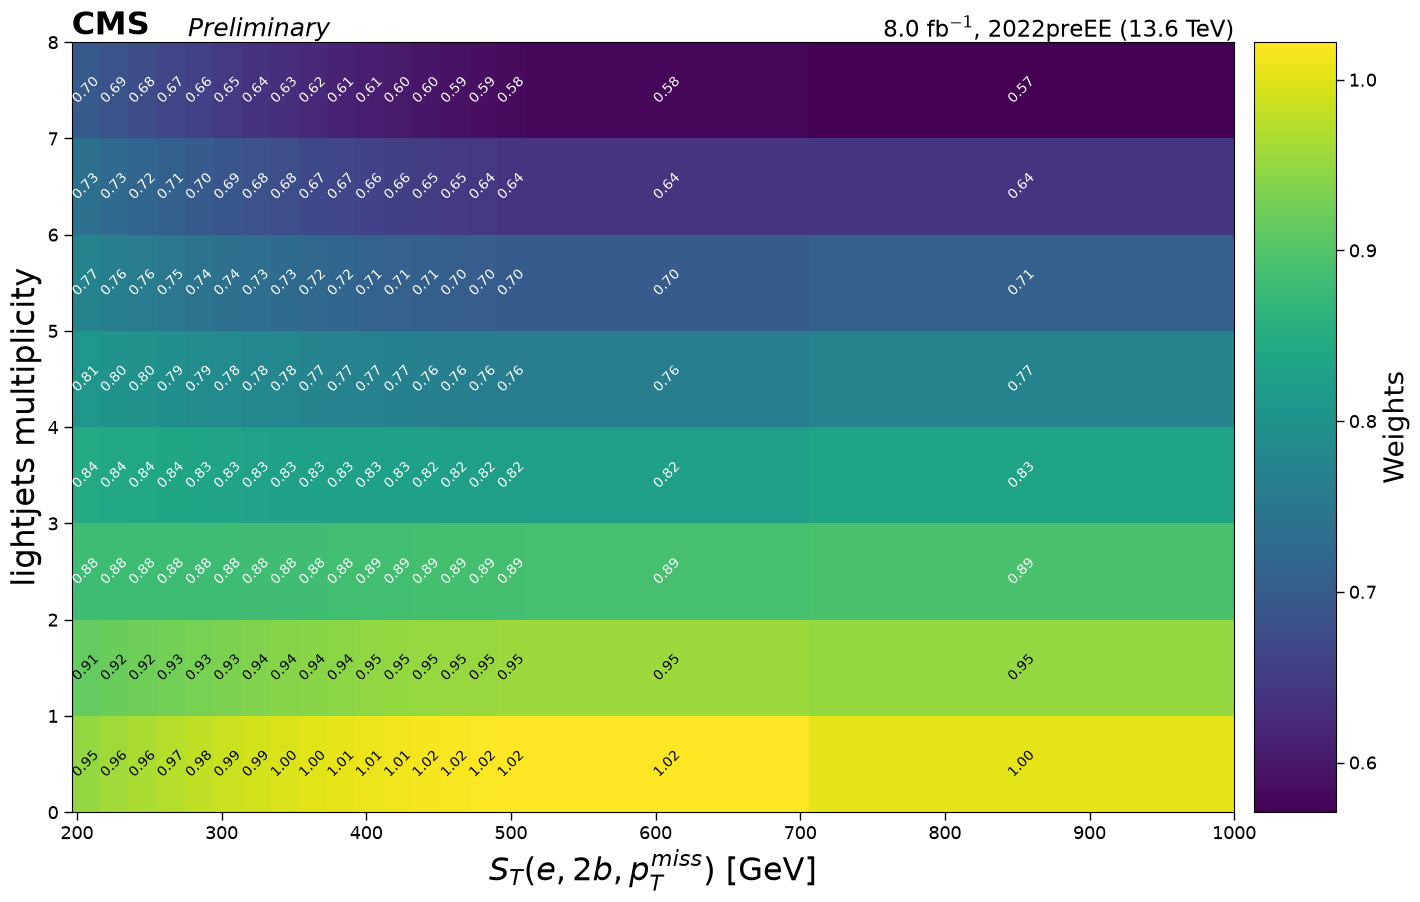

In [ ]:
st_bins = data.project("st").axes.edges[0]
n_jets_bins = data.project("lightjets_multiplicity").axes.edges[0]
st_centers = data.project("st").axes.centers[0]
jet_centers = data.project("lightjets_multiplicity").axes.centers[0]
st, jet_n = np.meshgrid(st_bins, n_jets_bins)
SF = boost_weight.to_evaluator().evaluate(st, jet_n)

data_matrix = np.zeros((len(st_bins)-1, len(n_jets_bins)-1))
for y in range(SF.shape[0]-1):
    for x in range(SF.shape[1]-1):
        data_matrix[x, y] = SF[y, x]

fig, ax = plt.subplots(figsize=(15, 10))
boost_hist = hist.Hist(*data.axes[:], data=data_matrix)
colormesh = boost_hist.plot2d(ax=ax)
colormesh[1].set_label("Weights", fontsize=20)
ax.set(xlabel=xlabels[workflow], ylabel="lightjets multiplicity")

for i in range(data_matrix.shape[0]):
    for j in range(data_matrix.shape[1]):
        val = data_matrix[i, j]
        x = st_centers[i]
        y = jet_centers[j]
        if val < 0.9 or np.isnan(val):
            col = 'w'
        else:
            col = 'k'
        ax.text(x, y, f"{val:.2f}", rotation=45, ha="center", va="center", fontsize=10, color=col)

hep.cms.label(
    ax=ax,
    lumi=round(lumi[year] * 1e-3, 1),
    com=energy[run_key].split()[0],
    data=True,
    year=year
)

ax.text(
    0.1, 1.00,
    r"$\mathit{Preliminary}$", 
    verticalalignment="bottom", 
    horizontalalignment="left", 
    transform=ax.transAxes, 
    fontsize=18
)
fig.savefig(f"plots/boost_weight_poly_{workflow}_{year}.png")
fig.savefig(f"plots/boost_weight_poly_{workflow}_{year}.pdf")

In [ ]:
cset = correctionlib.schemav2.CorrectionSet(
    schema_version=2,
    description="tt boost weight",
    corrections=[
        boost_weight
    ],
)
with gzip.open(f"../analysis/data/{year}_{workflow}_boost_weight.json.gz", "wt") as fout:
    fout.write(cset.model_dump_json(exclude_unset=True))